In [47]:
import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import seaborn as sns

import tensorflow
from tensorflow import keras
from tensorflow.keras import Sequential
from tensorflow.keras.layers import Dense,  Dropout, BatchNormalization
from sklearn.preprocessing import StandardScaler
from tensorflow.keras.callbacks import EarlyStopping
from sklearn.model_selection import train_test_split

In [48]:
data=pd.read_csv(r"C:\Users\maila\Downloads\diabetes.csv")

In [49]:
data.sample(10)

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
304,3,150,76,0,0,21.0,0.207,37,0
636,5,104,74,0,0,28.8,0.153,48,0
381,0,105,68,22,0,20.0,0.236,22,0
732,2,174,88,37,120,44.5,0.646,24,1
111,8,155,62,26,495,34.0,0.543,46,1
318,3,115,66,39,140,38.1,0.150,28,0
74,1,79,75,30,0,32.0,0.396,22,0
378,4,156,75,0,0,48.3,0.238,32,1
137,0,93,60,25,92,28.7,0.532,22,0
728,2,175,88,0,0,22.9,0.326,22,0


# Dataset EDA

In [50]:
data.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [51]:
data['Outcome'].value_counts()
# Imbalance Dataset

Outcome
0    500
1    268
Name: count, dtype: int64

In [52]:
data.corr()['Outcome']

Pregnancies                 0.221898
Glucose                     0.466581
BloodPressure               0.065068
SkinThickness               0.074752
Insulin                     0.130548
BMI                         0.292695
DiabetesPedigreeFunction    0.173844
Age                         0.238356
Outcome                     1.000000
Name: Outcome, dtype: float64

In [53]:
X=data.drop(columns='Outcome')
y=data.Outcome

In [54]:
X.shape, y.shape

((768, 8), (768,))

In [55]:
model=Sequential()
model.add(Dense(10, activation='relu', input_dim=8))
model.add(Dense(10, activation='relu'))
model.add(Dense(1, activation='sigmoid'))
model.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\layers\core\dense.py:95: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [56]:
callback=EarlyStopping(
    monitor='val_loss',
    patience=20,
    restore_best_weights=True,
    mode= 'max',
    min_delta=0.0001,
    verbose=1
)

In [57]:
model.summary()

Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_2 (Dense)                 │ (None, 10)             │            90 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           110 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_4 (Dense)                 │ (None, 1)              │            11 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 211 (844.00 B)

 Trainable params: 211 (844.00 B)

 Non-trainable params: 0 (0.00 B)

In [58]:
std=StandardScaler()
X=std.fit_transform(X)

In [59]:
history=model.fit(X, y, epochs=200, validation_split=0.2 , callbacks=[callback])

Epoch 1/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 2s 18ms/step - accuracy: 0.3860 - loss: 0.7743 - val_accuracy: 0.4026 - val_loss: 0.7518
Epoch 2/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5033 - loss: 0.7142 - val_accuracy: 0.5260 - val_loss: 0.7099
Epoch 3/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.6107 - loss: 0.6703 - val_accuracy: 0.6234 - val_loss: 0.6797
Epoch 4/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.6661 - loss: 0.6360 - val_accuracy: 0.6558 - val_loss: 0.6544
Epoch 5/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7117 - loss: 0.6089 - val_accuracy: 0.6818 - val_loss: 0.6334
Epoch 6/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7296 - loss: 0.5866 - val_accuracy: 0.7143 - val_loss: 0.6137
Epoch 7/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.7459 - loss: 0.5664 - val_accuracy: 0.7143 - val_loss: 0.5972
Epoch 8/200
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.7492 - loss: 0.5499 - val_accuracy: 0.7208 - 

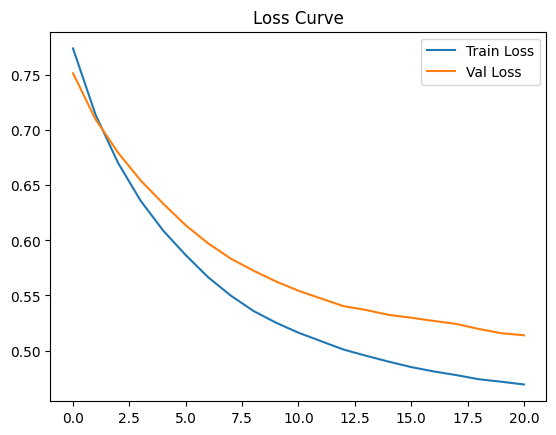

In [60]:
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Val Loss')
plt.legend()
plt.title('Loss Curve')
plt.show()

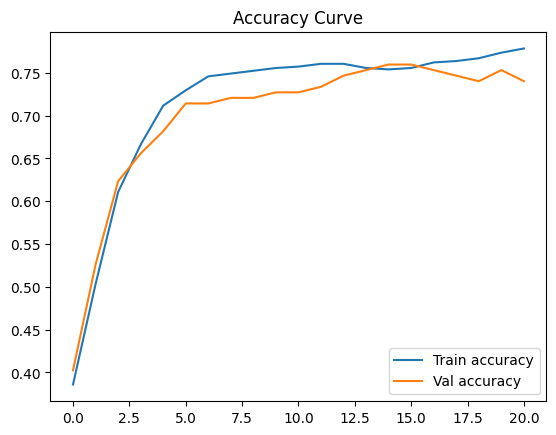

In [61]:
plt.plot(history.history['accuracy'], label='Train accuracy')
plt.plot(history.history['val_accuracy'], label='Val accuracy')
plt.legend()
plt.title('Accuracy Curve')
plt.show()

In [62]:
# tried different method sna dhyperparamters still the max acc model can reach is 80%, so now lets use keras tuner for
# hyperparameter tuning to see if we can get better accuracy

## **Keras Tuner**

In [63]:
import keras_tuner as kt

# To get best Optimizer out of all optimizers

In [64]:
def build_model(hp):
  model=Sequential()

  model.add(Dense(32, activation='relu', input_dim=8))
  model.add(Dense(1, activation='sigmoid'))

  optimizer=hp.Choice('optimizer', ['adam', 'sgd', 'rmsprop', 'adagrad'])

  model.compile(optimizer=optimizer, loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [65]:
tuner=kt.RandomSearch(build_model,
                      objective='val_accuracy',
                      max_trials=5)

Reloading Tuner from .\untitled_project\tuner0.json


In [66]:
X_train, X_test, y_train, y_test=train_test_split(X, y, test_size=0.2, random_state=42)

In [67]:
X_train.shape, X_test.shape

((614, 8), (154, 8))

In [68]:
tuner.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Trial 4 Complete [00h 00m 03s]
val_accuracy: 0.7532467246055603

Best val_accuracy So Far: 0.7532467246055603
Total elapsed time: 00h 02m 38s


In [69]:
print('Initializing a new Keras Tuner search with a different project name.')

# Initialize a new tuner with a different project_name
tuner_new = kt.RandomSearch(
    build_model,
    objective='val_accuracy',
    max_trials=5,
    project_name='new_tuner_project' # Specify a new project name here
)

print('Starting new search...')
# Run the new search
tuner_new.search(X_train, y_train, epochs=50, validation_data=(X_test, y_test))
print('\nNew search complete!')

Trial 4 Complete [00h 00m 12s]
val_accuracy: 0.7532467246055603

Best val_accuracy So Far: 0.7727272510528564
Total elapsed time: 00h 02m 07s

New search complete!


In [70]:
tuner_new.get_best_hyperparameters()[0].values

{'optimizer': 'adam'}

In [71]:
model=tuner_new.get_best_models(num_models=1)[0]

c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 10 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [72]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 32)             │           288 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            33 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 321 (1.25 KB)

 Trainable params: 321 (1.25 KB)

 Non-trainable params: 0 (0.00 B)

In [73]:
history=model.fit(X_train, y_train, epochs=100, callbacks=[callback], validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 3s 45ms/step - accuracy: 0.7866 - loss: 0.4242 - val_accuracy: 0.7727 - val_loss: 0.5242
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7850 - loss: 0.4217 - val_accuracy: 0.7792 - val_loss: 0.5241
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7850 - loss: 0.4211 - val_accuracy: 0.7662 - val_loss: 0.5251
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7866 - loss: 0.4205 - val_accuracy: 0.7468 - val_loss: 0.5265
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7866 - loss: 0.4202 - val_accuracy: 0.7468 - val_loss: 0.5265
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7883 - loss: 0.4195 - val_accuracy: 0.7532 - val_loss: 0.5273
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.7948 - loss: 0.4188 - val_accuracy: 0.7532 - val_loss: 0.5280
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7915 - loss: 0.4186 - val_accuracy: 0.

In [74]:
model=Sequential()
model.add(Dense(32, activation='relu', input_dim=8))
model.add(Dense(1, activation='sigmoid'))

model.compile(loss='binary_crossentropy', optimizer='RMSProp', metrics=['accuracy'])

In [75]:
history=model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 12ms/step - accuracy: 0.6091 - loss: 0.6511 - val_accuracy: 0.7078 - val_loss: 0.6135
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6645 - loss: 0.5961 - val_accuracy: 0.7208 - val_loss: 0.5795
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.6873 - loss: 0.5622 - val_accuracy: 0.7727 - val_loss: 0.5548
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7117 - loss: 0.5358 - val_accuracy: 0.7857 - val_loss: 0.5378
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7296 - loss: 0.5167 - val_accuracy: 0.7857 - val_loss: 0.5249
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7459 - loss: 0.5019 - val_accuracy: 0.7727 - val_loss: 0.5141
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7459 - loss: 0.4906 - val_accuracy: 0.7987 - val_loss: 0.5084
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7590 - loss: 0.4812 - val_accuracy: 0.7857 - 

In [76]:
model2=Sequential()
model2.add(Dense(32, activation='relu', input_dim=8))
model2.add(Dense(1, activation='sigmoid'))

model2.compile(loss='binary_crossentropy', optimizer='Adam', metrics=['accuracy'])

In [77]:
history2=model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test))

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.8127 - loss: 0.3968 - val_accuracy: 0.7662 - val_loss: 0.5329
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8127 - loss: 0.3963 - val_accuracy: 0.7662 - val_loss: 0.5329
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8143 - loss: 0.3961 - val_accuracy: 0.7662 - val_loss: 0.5336
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8192 - loss: 0.3956 - val_accuracy: 0.7662 - val_loss: 0.5350
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8111 - loss: 0.3953 - val_accuracy: 0.7662 - val_loss: 0.5364
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8176 - loss: 0.3942 - val_accuracy: 0.7597 - val_loss: 0.5376
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8192 - loss: 0.3946 - val_accuracy: 0.7597 - val_loss: 0.5393
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.8143 - loss: 0.3938 - val_accuracy: 0.7662 - v

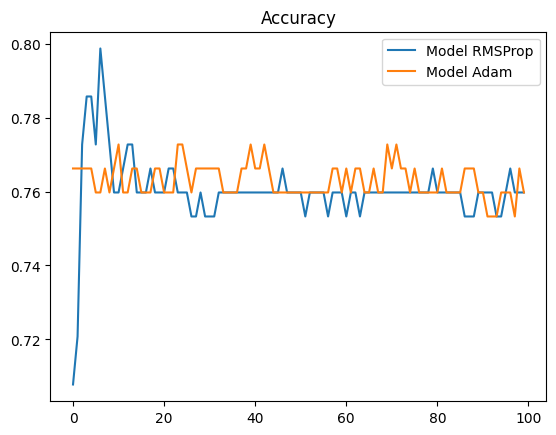

In [78]:
plt.plot(history.history['val_accuracy'], label="Model RMSProp")
plt.plot(history2.history['val_accuracy'], label="Model Adam")
plt.legend()
plt.title("Accuracy")
plt.show()

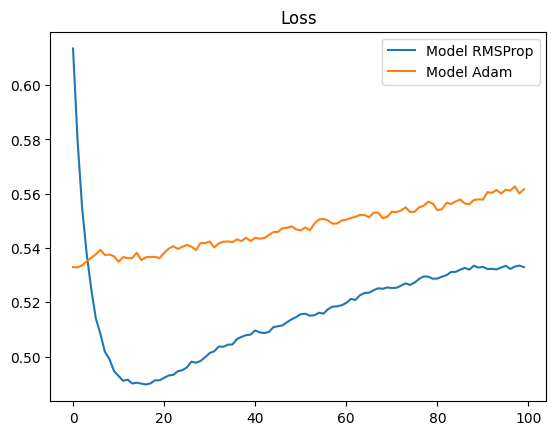

In [79]:
plt.plot(history.history['val_loss'], label="Model RMSProp")
plt.plot(history2.history['val_loss'], label="Model Adam")
plt.legend()
plt.title("Loss")
plt.show()

# best no. of Neuros in layer

In [80]:
def build_model(hp):
  model=Sequential()

  units=hp.Int('units', 8, 128, step=8)

  model.add(Dense(units=units, activation='relu', input_dim=8))
  model.add(Dense(1, activation='sigmoid'))\

  model.compile(optimizer='Adam', loss='binary_crossentropy', metrics=['accuracy'])

  return model

In [81]:
tuner_new3=kt.GridSearch(build_model,
                          directory='onNeuron',
                          project_name='second',
                          objective='val_accuracy',
                          max_trials=5)

In [82]:
tuner_new3.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Trial 5 Complete [00h 00m 04s]
val_accuracy: 0.7857142686843872

Best val_accuracy So Far: 0.7857142686843872
Total elapsed time: 00h 00m 17s


In [85]:
tuner_new3.get_best_hyperparameters()[0].values

{'units': 40}

In [86]:
model=tuner_new3.get_best_models(num_models=1)[0]

In [87]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 40)             │           360 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            41 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 401 (1.57 KB)

 Trainable params: 401 (1.57 KB)

 Non-trainable params: 0 (0.00 B)

In [88]:
history=model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=callback)

Epoch 1/100


20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 13ms/step - accuracy: 0.7638 - loss: 0.5395 - val_accuracy: 0.7857 - val_loss: 0.5423
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7541 - loss: 0.5162 - val_accuracy: 0.7727 - val_loss: 0.5289
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7541 - loss: 0.4999 - val_accuracy: 0.7597 - val_loss: 0.5201
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7622 - loss: 0.4877 - val_accuracy: 0.7532 - val_loss: 0.5148
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7590 - loss: 0.4791 - val_accuracy: 0.7727 - val_loss: 0.5112
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7590 - loss: 0.4725 - val_accuracy: 0.7597 - val_loss: 0.5082
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7573 - loss: 0.4667 - val_accuracy: 0.7597 - val_loss: 0.5077
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7687 - loss: 0.4617 - val_accuracy: 0.7597 - val_loss: 0.

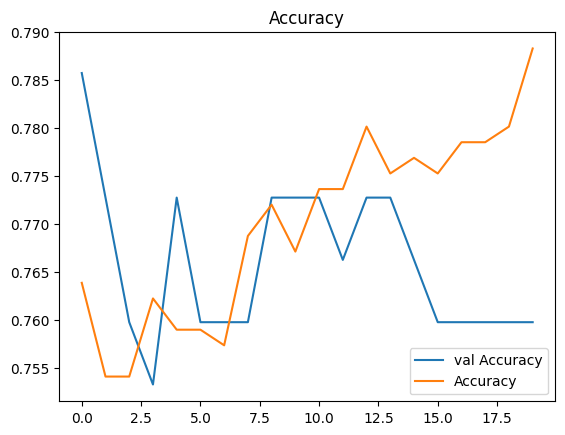

In [89]:
plt.plot(history.history['val_accuracy'], label="val Accuracy")
plt.plot(history.history['accuracy'], label="Accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

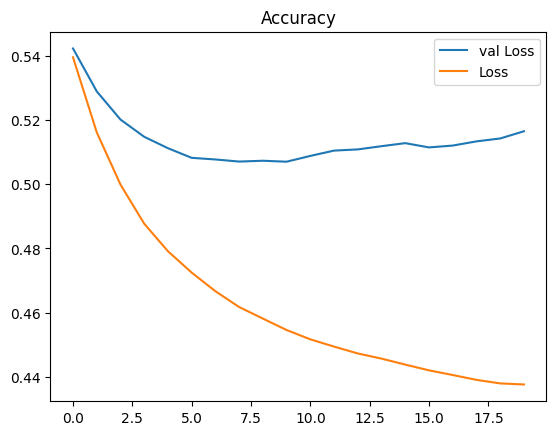

In [90]:
plt.plot(history.history['val_loss'], label="val Loss")
plt.plot(history.history['loss'], label="Loss")
plt.legend()
plt.title("Accuracy")
plt.show()

# Select number of layers

In [91]:
def build_model(hp):
  model=Sequential()

  model.add(Dense(24, activation='relu', input_dim=8))

  for i in range(hp.Int('num_leyers', min_value=1, max_value=10)):
    model.add(Dense(24, activation='relu'))

  model.add(Dense(1, activation='sigmoid'))

  model.compile(loss='binary_crossentropy', optimizer='adam', metrics=['accuracy'])
  return model

In [92]:
tuner3=kt.RandomSearch(build_model,
                       objective='val_accuracy',
                       directory='onLayer',
                       project_name='first',
                       max_trials=10)

In [93]:
tuner3.search(X_train, y_train, epochs=10, validation_data=(X_test, y_test))

Trial 10 Complete [00h 00m 06s]
val_accuracy: 0.7337662577629089

Best val_accuracy So Far: 0.7792207598686218
Total elapsed time: 00h 00m 48s


In [94]:
tuner3.get_best_hyperparameters()[0].values

{'num_leyers': 3}

In [95]:
model=tuner3.get_best_models(num_models=1)[0]

c:\Users\maila\AppData\Local\Programs\Python\Python310\lib\site-packages\keras\src\saving\saving_lib.py:797: UserWarning: Skipping variable loading for optimizer 'adam', because it has 2 variables whereas the saved optimizer has 22 variables. 
  saveable.load_own_variables(weights_store.get(inner_path))


In [96]:
history=model.fit(X_train, y_train, epochs=100, validation_data=(X_test, y_test), callbacks=callback)

Epoch 1/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 1s 17ms/step - accuracy: 0.7752 - loss: 0.4812 - val_accuracy: 0.7727 - val_loss: 0.5099
Epoch 2/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7801 - loss: 0.4644 - val_accuracy: 0.7597 - val_loss: 0.5167
Epoch 3/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7883 - loss: 0.4553 - val_accuracy: 0.7597 - val_loss: 0.5253
Epoch 4/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.7980 - loss: 0.4475 - val_accuracy: 0.7597 - val_loss: 0.5300
Epoch 5/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - accuracy: 0.8013 - loss: 0.4429 - val_accuracy: 0.7468 - val_loss: 0.5367
Epoch 6/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7964 - loss: 0.4347 - val_accuracy: 0.7208 - val_loss: 0.5402
Epoch 7/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.7980 - loss: 0.4308 - val_accuracy: 0.7468 - val_loss: 0.5372
Epoch 8/100
20/20 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7980 - loss: 0.4245 - val_accuracy: 0.7338 - 

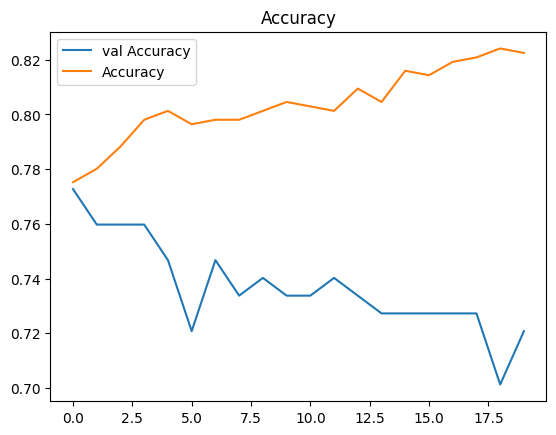

In [97]:
plt.plot(history.history['val_accuracy'], label="val Accuracy")
plt.plot(history.history['accuracy'], label="Accuracy")
plt.legend()
plt.title("Accuracy")
plt.show()

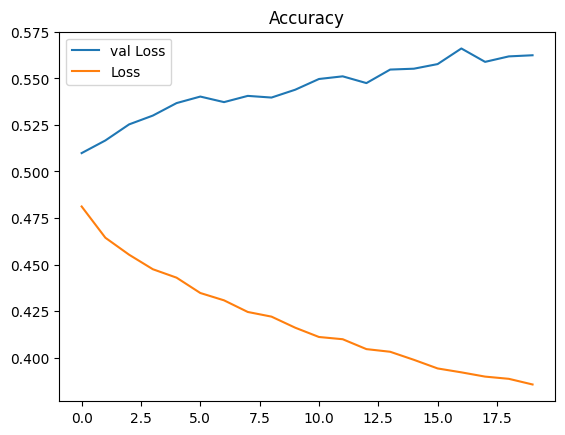

In [98]:
plt.plot(history.history['val_loss'], label="val Loss")
plt.plot(history.history['loss'], label="Loss")
plt.legend()
plt.title("Accuracy")
plt.show()